In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

c:\Users\webbd\Documents\phd\Scratch\thesis\figures\make_figure\ch4\fig_helper.py:371: SyntaxWarning: invalid escape sequence '\m'
  p1_name = "$\\varepsilon_\mathrm{corr}$"
c:\Users\webbd\Documents\phd\Scratch\thesis\figures\make_figure\ch4\fig_helper.py:403: SyntaxWarning: invalid escape sequence '\m'
  p1_name = "$\\varepsilon_\mathrm{corr}$"


In [3]:
def plot_data_fit(ax, df, m, popt):
    x_min = 0.5
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 1.2
    if m.name == "GT" or m.name == "PTM" or m.name == "SO3":
        reshape_fac = 4
        ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

        ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8, markersize=2)
        ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="$\\mathcal{P}_{DD}$", color="#017517", alpha=0.8, markersize=2)
        P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
        P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
        ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="$\\mathcal{P}_{SD}+\\mathcal{P}_{DS}$", color=gs.get_color(3), alpha=0.8, markersize=2)
        x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha())
        ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha())
        P0110_fit = P_fit[1] + P_fit[2]
        ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha())
        ax.set_ylabel("Pops.")
        # turn off legend for this subplot
        ax.legend().set_visible(False)

    
    ax.yaxis.set_label_coords(-0.2, 0.5)
    
    ax.set_xscale("log")
    ax.set_xticks([1, 1000])
    ax.set_yticks([0, 1/3, 2/3, 1])
    ax.set_yticklabels(["0", "$\\frac{1}{3}$", "$\\frac{2}{3}$", "1"])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)

    ax.set_xlabel("$m$", fontsize=9)
    ax.xaxis.set_label_coords(0.45, -0.1)

    # place legend in upper right corner


In [12]:
m = fh.SO3Model()

# injected noise vs. fitted noise for global stark shift noise
date = "2026-01-29"
rids = [92520, 92521, 92522, 92523, 92524, 92525, 92526, 92527, 92528, 92533, 92535, 92536, 92537, 92540, 92541]
sim_outcomes = [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ]

params = m.fit_mult_rbs(date, rids, sim_outcomes)
param1a, param2a, param3a, param4a = params


# injected noise vs. fitted noise for local stark shift noise
date = "2026-01-30"
rids = [92774, 92775, 92776, 92777, 92778, 92779, 92780, 92781, 92782, 92783]
sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, ]

params = m.fit_mult_rbs(date, rids, sim_outcomes)
param1b, param2b, param3b, param4b = params


Fitted a: 1.0000 ± 0.0000
Fitted y0: 0.0024 ± 0.0001
Fitted a: 1.0000 ± 0.0000
Fitted y0: 0.0027 ± 0.0003


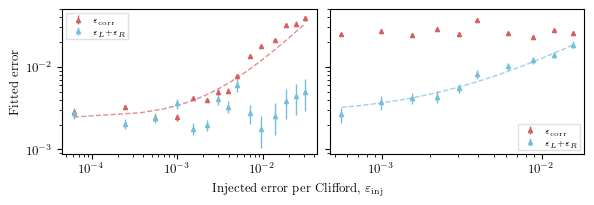

In [37]:
# plot first panel
def radians_to_errcliff(err_rad): 
    k = 1.16667 # sx and sz decomposition factor
    return k/3 * (err_rad)**2 

def inject_model(x, y0, a):
    return y0 + 1 * x

rad_a = np.array([0.004, 0.036, 0.028, 0.016, 0.012, 0.008, 0.032, 0.024, 0.02, 0.07, 0.09, 0.05, 0.06, 0.043, 0.08])*2*np.pi/2 # 1/2 factor as addressing two qubits
errsa = [radians_to_errcliff(err) for err in rad_a]

rad_b = np.array([0.028, 0.016, 0.012, 0.008, 0.032, 0.024, 0.02, 0.01, 0.014, 0.006, ])*2*np.pi
errsb = [radians_to_errcliff(err) for err in rad_b]

popt, pcov = curve_fit(inject_model, errsa, [t[0] for t in param1a], sigma=[t[1] for t in param1a], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
x_fit = np.linspace(min(errsa), max(errsa), 100)
I_fit = inject_model(x_fit, *popt)

fig_width = gs.get_fig_width()
fig_height = fig_width /3


fig, (ax, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(fig_width, fig_height),
                            layout="constrained", sharey=True)

ax.errorbar(errsa, [t[0] for t in param1a], yerr=[t[1] for t in param1a], fmt="^", label=m.p1_name, color=gs.get_color(2))
ax.errorbar(errsa, [t[0]+t1[0] for t,t1 in zip(param2a, param3a)], yerr=[t[1]+t1[1] for t,t1 in zip(param2a, param3a)], fmt="^", label=f"{m.p2_name}+{m.p3_name}", color=gs.get_color(5))

ax.plot(x_fit, I_fit, color=gs.get_color(2), alpha=gs.get_alpha())
ax.set_ylabel("Fitted error")

# plot second panel
x_fit = np.linspace(min(errsb), max(errsb), 100)
eLpR = [p2[0]+p3[0] for p2,p3 in zip(param2b, param3b)]
eLpR_err = [np.sqrt(p2[1]**2+p3[1]**2) for p2,p3 in zip(param2b, param3b)]

popt, pcov = curve_fit(inject_model, errsb, eLpR, sigma=eLpR_err, absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.49], [1.0, 1.51]))
print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
I_fit = inject_model(x_fit, *popt)

ax2.errorbar(errsb, [t[0] for t in param1b], yerr=[t[1] for t in param1b], fmt="^", label=m.p1_name, color=gs.get_color(2))
ax2.errorbar(errsb, eLpR, yerr=eLpR_err, fmt="^", label=f"{m.p2_name}+{m.p3_name}", color=gs.get_color(5))
ax2.plot(x_fit, I_fit, color=gs.get_color(5), alpha=gs.get_alpha())


ax2.legend(loc="lower right")
ax.legend(loc="upper left")
#log scale x
ax.set_yscale("log")
ax2.set_yscale("log")
ax.set_xscale("log")
ax2.set_xscale("log")
ax.grid(False)
ax2.grid(False)
#ax.set_yticks([1e-3, 1e-2, 1e-1])

fig.supxlabel('Injected error per Clifford, $\\varepsilon_\\mathrm{inj}$', fontsize=9)
plt.show()
f_path = "..\\..\\pdf_figure\\ch4\\stark_noise.pdf"
fig.savefig(f_path)